# Lab work: Random variables

### 1 Analysing an experiment with reactivity responses (response times)


Let us consider an experiment that records the time lapses of a subject’s responses with respect to a stimulus onset.  
We model these time lapses as a tuple of random variables \((T_i)_{i=0}^n\), all \(T_i\) being mutually independent (an experiment consisting of \(n\) independent trials).

We suppose that the random variables \(T_i\) are distributed according to a law specified by the prototypical random variable \(T\) in the family of the **Inverse Gaussian distribution**, i.e. the probability density function reads:

$$
f_T(t;\mu,\lambda)
=
\sqrt{\frac{\lambda}{2\pi t^3}}
\exp\left(
-\frac{\lambda (t - \mu)^2}{2 \mu^2 t}
\right)
\quad \text{for all } t \ge 0,\; (\mu,\lambda) \in \mathbb{R}_{\ge 0}^2.
$$

with parameters \(\mu = 120\,\text{ms}\) and \(\lambda = 40\,\text{ms}\).

In what follows, our objective is to generate multiple such tuples \((T_i)_{i=1}^n\) and study the estimation of various statistical properties of \(T\) under the influence of a varying \(n\).


#### 1.1 Generating random variables from a given distribution law: simulating the experiment outcomes

In [2]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

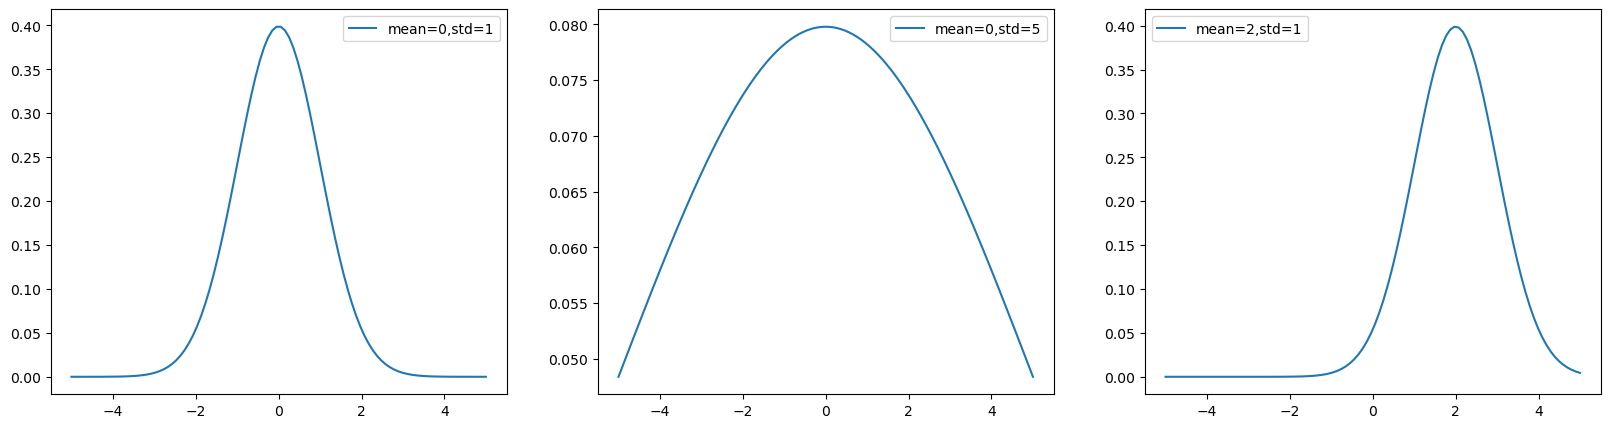

In [61]:
# create an index
x=np.linspace(-5,5,100)

# set probability densition functions  with diffent loc and scale
y0=stats.norm.pdf(x,loc=0,scale=1)
y1=stats.norm.pdf(x,loc=0,scale=5)
y2=stats.norm.pdf(x,loc=2,scale=1)

# plot the density functions
fig,ax=plt.subplots(1,3,figsize=(20,5))
ax[0].plot(x,y0,label='mean=0,std=1')
ax[1].plot(x,y1,label='mean=0,std=5')
ax[2].plot(x,y2,label='mean=2,std=1')
for i in range(3):
    ax[i].legend()
plt.show()

So we can see that loc corresponds to the mean of the distribution, changing its value leads to an horizontal sift of the probability density function. In signal and system term it could be seen as a time sift of a signal. 

The scale corresponds to the standard deviation of the distribution, changing its value leads to a change of the spread around the mean. In signal and system terms it could been seen as time scaling.

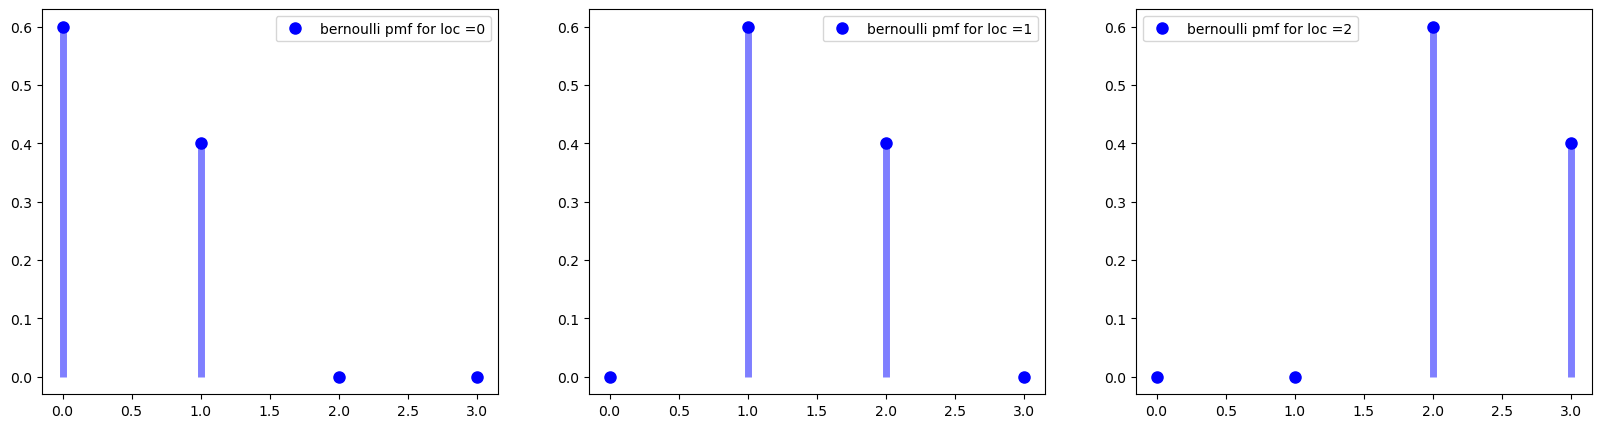

In [142]:
# set p
p=0.4

# create an index
x = np.arange(0,4)

# plot the probability mass functions
fig,ax=plt.subplots(1,3,figsize=(20,5))
ax[0].plot(x, stats.bernoulli.pmf(x, p,loc=0), 'bo', ms=8, label='bernoulli pmf for loc =0')
ax[0].vlines(x, 0, stats.bernoulli.pmf(x, p,loc=0), colors='b', lw=5, alpha=0.5)

ax[1].plot(x, stats.bernoulli.pmf(x, p,loc=1), 'bo', ms=8, label='bernoulli pmf for loc =1')
ax[1].vlines(x, 0, stats.bernoulli.pmf(x, p,loc=1), colors='b', lw=5, alpha=0.5)

ax[2].plot(x, stats.bernoulli.pmf(x, p,loc=2), 'bo', ms=8, label='bernoulli pmf for loc =2')
ax[2].vlines(x, 0, stats.bernoulli.pmf(x, p,loc=2), colors='b', lw=5, alpha=0.5)
for i in range(3):
    ax[i].legend()
plt.show()

Loc and scale are not relevant to the variable p, as we can see on the plot above, changing the value of loc leads to shift on the x-axis but do not change the look of the two probabilities. And scale modulate the spread around a value point on a continuous distribution, here we are on a categorical distribution. 

In [185]:
def m (nu,Lambda):
    return nu/Lambda
def l(nu,Lambda):
    return 0
def s(nu,Lambda):
    return Lambda

nu=120e-3
Lambda=40e-3

T=stats.invgauss(mu=m(nu,Lambda),loc=l(nu,Lambda),scale=s(nu,Lambda))

In [189]:
print(f'The first moment is equal to {T.moment(1)} exactly as the mean nu.')
print(f'The first moment is equal to {T.moment(2)-T.moment(1)**2} exactly as the cubic nu divided by lambda.')

The first moment is equal to 0.12 exactly as the mean nu.
The first moment is equal to 0.0432 exactly as the cubic nu divided by lambda.


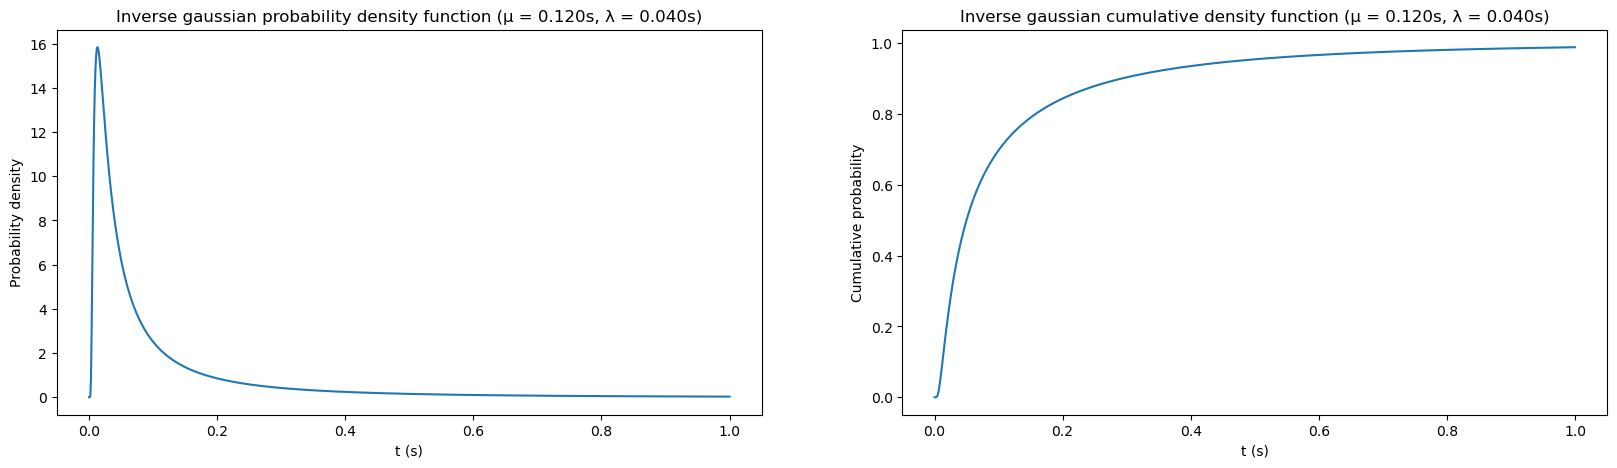

In [194]:
# create index, a RT can't be inferior to 0 and it's rare to be superior to one second
t = np.linspace(0, 1, 1000)

# create subplots
fig,ax=plt.subplots(1,2,figsize=(20,5))

ax[0].plot(t, T.pdf(t))
ax[0].set_title("Inverse gaussian probability density function (μ = {:.3f}s, λ = {:.3f}s)".format(nu, Lambda))
ax[0].set_xlabel("t (s)")
ax[0].set_ylabel("Probability density")

ax[1].plot(t, T.cdf(t))
ax[1].set_title("Inverse gaussian cumulative density function (μ = {:.3f}s, λ = {:.3f}s)".format(nu, Lambda))
ax[1].set_xlabel("t (s)")
ax[1].set_ylabel("Cumulative probability")
plt.show()

### 1.2 Empirical distribution of the data

The above laws give access to the probability density function, the cumulative density function, and related
quantities (e.g., expectations). But what if you observe samples that have been generated according to this
distribution — how do these distribute? Of course, you will no longer be able to observe the density function
directly, but local densities of the samples should relate to local densities of the random variable by a law of
large numbers.

We will first have a look at the Bernoulli distribution and try to estimate $p$ from the observed samples.
Suppose our samples are

$$
(B_i)_{i=0}^{n-1} = (b_i)_{i=0}^{n-1}, \qquad b_i \in \{0,1\}.
$$

The proportion of samples that take the value one should be comparable to the theoretical proportion

$$
\mathbb{E}[B] = 0 \cdot (1 - p) + 1 \cdot p = p,
$$

i.e.

$$
\frac{1}{n} \sum_{i=0}^{n-1} b_i \xrightarrow[n\to\infty]{} p.
$$

Indeed, the law of large numbers states that for $(B_i)_{i=0}^{n-1}$ mutually uncorrelated (and of finite
mean and variance), we have

$$
\mathbb{E}\left[ \frac{1}{n} \sum_{i=0}^{n-1} B_i \right] = \mathbb{E}[B] = p,
$$

and

$$
\mathrm{Var}\left[ \frac{1}{n} \sum_{i=0}^{n-1} B_i \right]
= \frac{\sigma_B^2}{n}
= \frac{p(1-p)}{n}
\xrightarrow[n\to\infty]{} 0.
$$


In [207]:
# Set parameter p, between 0 and 1, because you can't have a probability superior to one nor inferior to 0
p = 0.3

# Values of n to test
N = [10, 100, 1000]

# Number of repetitions for each n
nb_rep = 20

# Storage for results
results = {}

for n in N:
    # Store empirical mean for each repetition
    empirical_means = []
    # Go through the loop for the number of repetition set
    for i in range(nb_rep):
        samples = stats.bernoulli(p).rvs(size=n)
        m = samples.mean()
        empirical_means.append(float(m))
    # Create a n-key and associate the list of all the empirical means for the 20 repetitions
    results[n] = empirical_means

# Print results
print(f"True p = {p}")
print('-'*100)
for n in N:
    print(f"For n = {n} : empirical means for {nb_rep} repetitions :")
    print(results[n])
    print(f"Average empirical mean ≈ {np.mean(results[n])}\n")

True p = 0.3
----------------------------------------------------------------------------------------------------
For n = 10 : empirical means for 20 repetitions :
[0.4, 0.3, 0.4, 0.1, 0.5, 0.6, 0.1, 0.4, 0.4, 0.6, 0.6, 0.2, 0.3, 0.3, 0.0, 0.2, 0.2, 0.4, 0.4, 0.2]
Average empirical mean ≈ 0.33000000000000007

For n = 100 : empirical means for 20 repetitions :
[0.3, 0.25, 0.25, 0.3, 0.32, 0.28, 0.3, 0.31, 0.26, 0.3, 0.36, 0.41, 0.32, 0.29, 0.37, 0.37, 0.31, 0.31, 0.26, 0.23]
Average empirical mean ≈ 0.30499999999999994

For n = 1000 : empirical means for 20 repetitions :
[0.306, 0.294, 0.307, 0.306, 0.277, 0.33, 0.309, 0.289, 0.323, 0.301, 0.297, 0.316, 0.308, 0.297, 0.3, 0.294, 0.277, 0.334, 0.283, 0.302]
Average empirical mean ≈ 0.3025

